# Eye Disease Detection - Improved Deep Learning Model

**Author:** Steven  
**Project:** Fundus Image Classification for Ocular Disease Detection  
**Dataset:** ODIR-5K  

This notebook implements an improved deep learning model with:
- Separate augmentation for train/validation
- Better model architecture (ResNet34)
- Learning rate scheduling
- Comprehensive evaluation metrics
- Advanced visualizations

# 1. Setup and Installation

## 1.1 Install Dependencies

In [1]:
# Install required packages
!pip install -q kaggle pandas numpy matplotlib seaborn opencv-python torch torchvision tqdm scikit-learn

## 1.2 Kaggle Authentication and Dataset Download

In [2]:
from google.colab import files

# Upload Kaggle API key
print("Upload your kaggle.json API key file (from https://www.kaggle.com/settings/account).")
files.upload()

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download ODIR-5K dataset
!kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k
!unzip -q ocular-disease-recognition-odir5k.zip -d odir5k

Upload your kaggle.json API key file (from https://www.kaggle.com/settings/account).


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k
License(s): other
 94% 1.53G/1.62G [00:01<00:00, 959MB/s]
100% 1.62G/1.62G [00:01<00:00, 1.21GB/s]


## 1.3 Import Libraries

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from collections import defaultdict
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.9.0+cu126
CUDA available: True


# 2. Data Loading and Preprocessing

## 2.1 Load metadata, build per-eye labels, split by patient

Deduplicates images, derives **per-eye** Normal/Abnormal labels from the diagnostic keywords, and splits **grouped by patient** so no patient (or image) leaks across train/val/test.

In [ ]:
# Data preparation: deduplicated PER-EYE labels with a PATIENT-GROUPED split.
#
# Fixes vs. the original pipeline:
#  - Each physical image is used EXACTLY ONCE. The old loop over both eyes of
#    every CSV row duplicated each image ~1.95x (12,460 "pairs" from 6,392 images).
#  - Labels are PER-EYE (from the eye's own diagnostic keyword), not the noisy
#    patient-level Normal flag.
#  - The split is grouped by patient, so no patient (hence no image) appears in
#    more than one of train/val/test -> removes the train/test leakage.
import os, re
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

# Auto-detect data location (Colab Kaggle download vs. local repo checkout).
_CANDIDATES = [
    ("odir5k/full_df.csv", "odir5k/preprocessed_images"),
    ("data/full_df.csv",   "data/preprocessed_images"),
    ("full_df.csv",        "preprocessed_images"),
]
CSV_PATH, IMAGE_DIR = next(((c, i) for c, i in _CANDIDATES
                            if os.path.exists(c) and os.path.isdir(i)), _CANDIDATES[0])
RANDOM_STATE = 42
print(f"CSV_PATH  = {CSV_PATH}\nIMAGE_DIR = {IMAGE_DIR}")

# Non-pathological capture artifacts: an eye whose only non-"normal fundus"
# tokens are these is still Normal (they describe image quality, not disease).
ARTIFACT_TOKENS = {"lens dust", "low image quality"}
NORMAL_TOKEN = "normal fundus"

# 1. CSV -> long, one-row-per-eye table.
df = pd.read_csv(CSV_PATH)
_left = df[["ID", "Left-Fundus", "Left-Diagnostic Keywords"]].rename(
    columns={"ID": "patient_id", "Left-Fundus": "filename", "Left-Diagnostic Keywords": "keywords"})
_left["side"] = "left"
_right = df[["ID", "Right-Fundus", "Right-Diagnostic Keywords"]].rename(
    columns={"ID": "patient_id", "Right-Fundus": "filename", "Right-Diagnostic Keywords": "keywords"})
_right["side"] = "right"
eyes = pd.concat([_left, _right], ignore_index=True)

# 2. Deduplicate to physical images that exist on disk (each used exactly once).
disk_files = set(os.listdir(IMAGE_DIR))
n_referenced = eyes["filename"].nunique()
eyes = eyes[eyes["filename"].isin(disk_files)].copy()
n_missing = n_referenced - eyes["filename"].nunique()
assert (eyes.groupby("filename")["keywords"].nunique() <= 1).all(), "conflicting keywords for a filename"
eyes = eyes.drop_duplicates(subset="filename").reset_index(drop=True)
eyes["path"] = eyes["filename"].apply(lambda f: os.path.join(IMAGE_DIR, f))

# 3. Per-eye binary label: Normal (0) iff the only meaningful keyword token is
#    "normal fundus"; otherwise Abnormal (1). Handles the full-width "," separator.
def keyword_to_label(kw):
    tokens = [t.strip().lower() for t in re.split(r"[，,]", str(kw)) if t.strip()]
    meaningful = [t for t in tokens if t not in ARTIFACT_TOKENS]
    return 0 if (meaningful and all(t == NORMAL_TOKEN for t in meaningful)) else 1
eyes["label"] = eyes["keywords"].apply(keyword_to_label)
dataset = eyes[["path", "label", "patient_id"]].copy()

# 4. Patient-grouped, label-stratified split: ~70% train / 15% val / 15% test.
_sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=RANDOM_STATE)
_tv_idx, _te_idx = next(_sgkf.split(np.arange(len(dataset)), dataset["label"].values, dataset["patient_id"].values))
trainval = dataset.iloc[_tv_idx].reset_index(drop=True)
test_df  = dataset.iloc[_te_idx].reset_index(drop=True)
_sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=RANDOM_STATE)
_tr_idx, _va_idx = next(_sgkf2.split(np.arange(len(trainval)), trainval["label"].values, trainval["patient_id"].values))
train_df = trainval.iloc[_tr_idx].reset_index(drop=True)
val_df   = trainval.iloc[_va_idx].reset_index(drop=True)

# 5. Prove no leakage.
def _stats(name, d):
    print(f"  {name:5s}: {len(d):5d} images | {d['patient_id'].nunique():5d} patients | {100*d['label'].mean():5.1f}% abnormal")
print(f"Referenced filenames: {n_referenced} | missing on disk (skipped): {n_missing}")
print(f"Total UNIQUE images used: {len(dataset)} | overall {100*dataset['label'].mean():.1f}% abnormal")
_stats("train", train_df); _stats("val", val_df); _stats("test", test_df)
_ptr, _pva, _pte = set(train_df.path), set(val_df.path), set(test_df.path)
_gtr, _gva, _gte = set(train_df.patient_id), set(val_df.patient_id), set(test_df.patient_id)
assert not (_ptr & _pva) and not (_ptr & _pte) and not (_pva & _pte), "IMAGE PATH LEAKAGE"
assert not (_gtr & _gva) and not (_gtr & _gte) and not (_gva & _gte), "PATIENT LEAKAGE"
assert len(train_df) + len(val_df) + len(test_df) == len(dataset)
print("✓ No image-path or patient leakage across splits.")

# 3. Data Augmentation and Transforms

## 3.1 Define Separate Transforms for Training and Validation

**IMPROVEMENT:** Separate transforms prevent data leakage and ensure reliable validation metrics

In [6]:
# Training transform - WITH augmentation
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=(0.7, 1.3),
        contrast=0.2,
        saturation=0.2
    ),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        shear=5
    ),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transform - NO augmentation
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Training transform: WITH augmentation")
print("✓ Validation transform: WITHOUT augmentation")

✓ Training transform: WITH augmentation
✓ Validation transform: WITHOUT augmentation


## 3.2 Define Custom Dataset Class

In [ ]:
class FundusDataset(Dataset):
    """Fundus image dataset.

    Expects a DataFrame with columns:
      - 'path'  : path to the image file
      - 'label' : int, 0 = Normal, 1 = Abnormal
    The int label is converted internally to a 2-element one-hot float tensor
    [Normal, Abnormal] to match the model's 2-output Sigmoid + BCELoss head.
    """

    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        try:
            img = cv2.imread(img_path)
            if img is None:
                raise ValueError(f"Could not read image: {img_path}")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            img = np.zeros((224, 224, 3), dtype=np.uint8)

        if self.transform:
            img = self.transform(img)

        # int label -> one-hot [Normal, Abnormal]
        y = int(row['label'])
        label = torch.tensor([1.0 - y, float(y)], dtype=torch.float32)
        return img, label

print("✓ Dataset class defined (int label -> one-hot [Normal, Abnormal])")

## 3.3 Create Datasets and Data Loaders

In [ ]:
# Datasets + loaders from the patient-grouped splits built above.
train_ds = FundusDataset(train_df, transform=train_transform)
val_ds   = FundusDataset(val_df,   transform=val_transform)
test_ds  = FundusDataset(test_df,  transform=val_transform)

BATCH_SIZE = 16
# drop_last avoids a size-1 final train batch breaking BatchNorm1d.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"✓ Data loaders created (batch size: {BATCH_SIZE})")
print(f"  train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")

## 3.4 Analyze Class Distribution

In [ ]:
# Class distribution in the training set (computed directly from labels).
normal_count   = int((train_df['label'] == 0).sum())
abnormal_count = int((train_df['label'] == 1).sum())
counts = np.array([normal_count, abnormal_count])
label_names = ['Normal', 'Abnormal']
print("Class distribution in training set:")
for name, count in zip(label_names, counts):
    print(f"  {name}: {count} samples ({count/len(train_df)*100:.1f}%)")

plt.figure(figsize=(8, 5))
sns.barplot(x=label_names, y=counts, palette='viridis')
plt.title("Class Distribution in Training Set", fontsize=14, fontweight='bold')
plt.ylabel("Number of Images"); plt.xlabel("Class")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 3.5 Visualize Sample Images

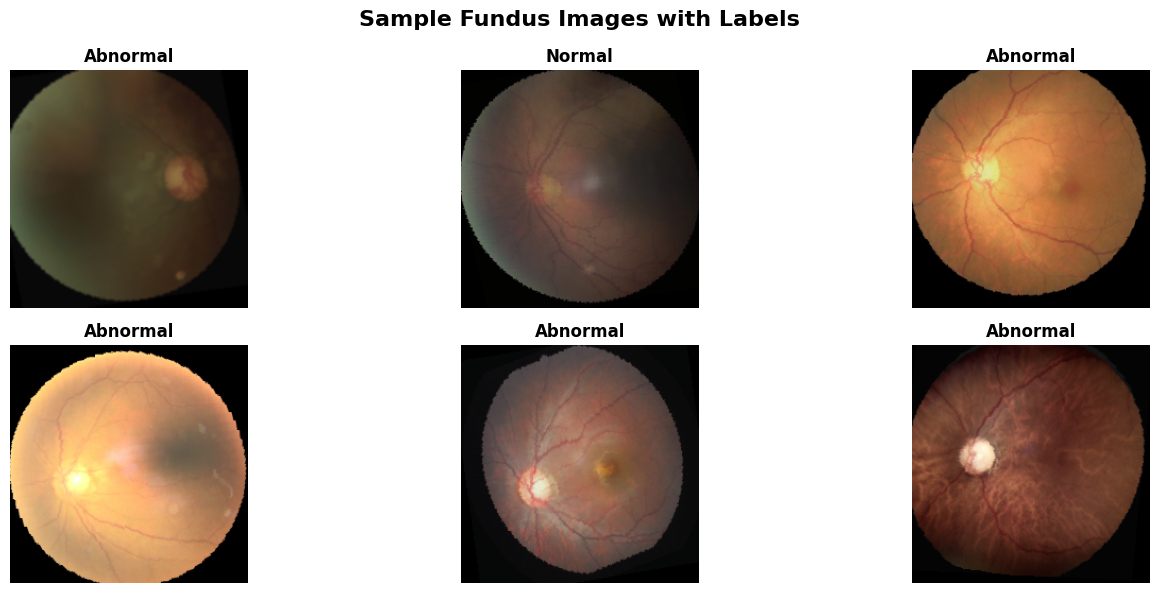

In [10]:
import random

# Display random sample images
plt.figure(figsize=(15, 6))
for i, idx in enumerate(random.sample(range(len(train_ds)), 6)):
    img, label = train_ds[idx]

    # Denormalize for visualization
    img_display = img.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)

    plt.subplot(2, 3, i+1)
    plt.imshow(img_display)
    class_name = "Normal" if label[0].item() == 1 else "Abnormal"
    plt.title(f"{class_name}", fontweight='bold')
    plt.axis('off')

plt.suptitle("Sample Fundus Images with Labels", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Model Architecture

## 4.1 Define Improved Model Architecture

**IMPROVEMENTS:**
- ResNet34 instead of ResNet18 (more capacity)
- Better classifier with BatchNorm
- Dropout for regularization

In [11]:
class ImprovedResNetModel(nn.Module):
    """Improved ResNet with better regularization and architecture"""

    def __init__(self, num_classes=2, dropout=0.5, backbone='resnet34'):
        super(ImprovedResNetModel, self).__init__()

        # Load pretrained ResNet34
        if backbone == 'resnet34':
            self.backbone = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
            num_features = 512
        elif backbone == 'resnet50':
            self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            num_features = 2048
        else:
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            num_features = 512

        # Remove final FC layer
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-1])

        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output

print("✓ Improved model architecture defined")

✓ Improved model architecture defined


## 4.2 Initialize Model and Training Components

In [ ]:
# Device: CUDA -> MPS (Apple Silicon) -> CPU
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")
device = get_device()
print(f"Using device: {device}")

# Initialize model
model = ImprovedResNetModel(num_classes=2, dropout=0.5, backbone='resnet34').to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Class weights from the TRAIN split (balances the BCE loss). float32 for MPS.
total_samples = normal_count + abnormal_count
weight_normal   = total_samples / (2 * normal_count)
weight_abnormal = total_samples / (2 * abnormal_count)
class_weights = torch.tensor([weight_normal, weight_abnormal], device=device, dtype=torch.float32)
print(f"\nClass weights: Normal={weight_normal:.3f}, Abnormal={weight_abnormal:.3f}")

criterion = nn.BCELoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
print("\n✓ Model, optimizer, and scheduler initialized")

# 5. Training

## 5.1 Define Training Functions

In [13]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == labels).all(dim=1).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def validate_epoch(model, loader, criterion, device):
    """Validate and return predictions"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Validating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return total_loss / len(loader), all_preds, all_labels


def plot_training_metrics(history):
    """Plot training metrics in real-time"""
    clear_output(wait=True)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0, 0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy
    axes[0, 1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs_range, history['val_acc'], 'r-o', label='Val Acc', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0, 1])

    # F1 Score
    axes[1, 0].plot(epochs_range, history['val_f1'], 'g-o', label='Val F1', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].set_title('F1 Score', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0, 1])

    # Learning Rate
    axes[1, 1].plot(epochs_range, history['lr'], 'm-o', label='Learning Rate', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')

    plt.tight_layout()
    plt.show()

print("✓ Training functions defined")

✓ Training functions defined


## 5.2 Run Training Loop

**IMPROVEMENTS:**
- Learning rate scheduling
- Early stopping with patience
- Real-time visualization
- Model checkpointing

In [ ]:
# Training configuration
SMOKE_TEST = False          # True -> 2 epochs, for a quick end-to-end sanity run
EPOCHS = 2 if SMOKE_TEST else 50
PATIENCE = 10
best_val_loss = float('inf')
best_epoch = -1
trigger_times = 0

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': [], 'lr': []}

print("=" * 70); print("STARTING TRAINING"); print("=" * 70)
print(f"Device: {device} | Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | Patience: {PATIENCE}")
print("=" * 70)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}"); print("-" * 70)
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_preds, val_labels = validate_epoch(model, val_loader, criterion, device)

    val_preds_binary = (val_preds > 0.5).astype(int)
    y_true = val_labels[:, 1].astype(int)
    y_pred = val_preds_binary[:, 1].astype(int)
    TP = int(np.sum((y_true == 1) & (y_pred == 1))); TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1))); FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    val_acc   = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # store plain python floats so the checkpoint loads cleanly (no numpy scalars)
    history['train_loss'].append(float(train_loss)); history['val_loss'].append(float(val_loss))
    history['train_acc'].append(float(train_acc));   history['val_acc'].append(float(val_acc))
    history['val_f1'].append(float(f1));             history['lr'].append(float(optimizer.param_groups[0]['lr']))

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"Precision:  {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f} | TP:{TP} TN:{TN} FP:{FP} FN:{FN}")

    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = float(val_loss); best_epoch = epoch; trigger_times = 0
        # full checkpoint (metadata) + a pure-weights file that always loads under weights_only=True
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': float(val_loss), 'val_acc': float(val_acc), 'history': history}, 'best_model.pth')
        torch.save(model.state_dict(), 'best_model_weights.pth')
        print("✓ Saved best model")
    else:
        trigger_times += 1
        print(f"⚠ No improvement for {trigger_times} epochs")
        if trigger_times >= PATIENCE:
            print(f"\n\U0001f6d1 Early stopping after {PATIENCE} epochs without improvement"); break

    plot_training_metrics(history)

print("\n" + "=" * 70); print("TRAINING COMPLETED"); print("=" * 70)
print(f"Best validation loss: {best_val_loss:.4f} (epoch {best_epoch+1})")

## 5.3 Load Best Model

In [ ]:
# Load the best checkpoint for evaluation.
# torch>=2.6 defaults weights_only=True, which raises UnpicklingError on the
# numpy scalars stored in older checkpoints -> the ORIGINAL load silently failed
# and evaluation ran on stale last-epoch weights. Prefer the pure-weights file
# (loads under weights_only=True); fall back to the full checkpoint with
# weights_only=False (safe: it is our own trusted local file).
import torch
try:
    state = torch.load('best_model_weights.pth', map_location=device)
    model.load_state_dict(state); model.to(device)
    print("✓ Loaded best model weights from best_model_weights.pth")
except FileNotFoundError:
    checkpoint = torch.load('best_model.pth', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict']); model.to(device)
    print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")
    print(f"  Validation Loss: {checkpoint['val_loss']:.4f} | Val Acc: {checkpoint['val_acc']:.4f}")
model.eval()

# 6. Comprehensive Model Evaluation

## 6.1 Define Evaluation Class

In [17]:
class ModelEvaluator:
    """Comprehensive model evaluation with multiple metrics and visualizations"""

    def __init__(self, model, device, class_names=['Normal', 'Abnormal']):
        self.model = model
        self.device = device
        self.class_names = class_names

    def evaluate(self, dataloader, threshold=0.5):
        """Run comprehensive evaluation"""
        self.model.eval()

        all_preds = []
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for imgs, labels in tqdm(dataloader, desc="Evaluating"):
                imgs = imgs.to(self.device)
                outputs = self.model(imgs)

                all_probs.append(outputs.cpu().numpy())
                all_labels.append(labels.numpy())

        all_probs = np.concatenate(all_probs, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)
        all_preds = (all_probs > threshold).astype(int)

        return self._calculate_metrics(all_labels, all_preds, all_probs)

    def _calculate_metrics(self, y_true, y_pred, y_prob):
        """Calculate comprehensive metrics"""
        metrics = {}

        # Focus on 'Abnormal' class (index 1)
        y_true_binary = y_true[:, 1].astype(int)
        y_pred_binary = y_pred[:, 1].astype(int)
        y_prob_binary = y_prob[:, 1]

        # Confusion matrix
        TP = np.sum((y_true_binary == 1) & (y_pred_binary == 1))
        TN = np.sum((y_true_binary == 0) & (y_pred_binary == 0))
        FP = np.sum((y_true_binary == 0) & (y_pred_binary == 1))
        FN = np.sum((y_true_binary == 1) & (y_pred_binary == 0))

        metrics['confusion_matrix'] = {
            'TP': int(TP), 'TN': int(TN), 'FP': int(FP), 'FN': int(FN)
        }

        # Basic metrics
        metrics['accuracy'] = (TP + TN) / (TP + TN + FP + FN)
        metrics['precision'] = TP / (TP + FP) if (TP + FP) > 0 else 0
        metrics['recall'] = TP / (TP + FN) if (TP + FN) > 0 else 0
        metrics['specificity'] = TN / (TN + FP) if (TN + FP) > 0 else 0
        metrics['f1_score'] = 2 * (metrics['precision'] * metrics['recall']) / \
                             (metrics['precision'] + metrics['recall']) \
                             if (metrics['precision'] + metrics['recall']) > 0 else 0

        # Advanced metrics
        metrics['balanced_accuracy'] = balanced_accuracy_score(y_true_binary, y_pred_binary)
        metrics['matthews_corr_coef'] = matthews_corrcoef(y_true_binary, y_pred_binary)
        metrics['cohen_kappa'] = cohen_kappa_score(y_true_binary, y_pred_binary)

        # NPV and PPV
        metrics['npv'] = TN / (TN + FN) if (TN + FN) > 0 else 0
        metrics['ppv'] = metrics['precision']

        # ROC and PR AUC
        fpr, tpr, _ = roc_curve(y_true_binary, y_prob_binary)
        metrics['roc_auc'] = auc(fpr, tpr)
        metrics['roc_curve'] = {'fpr': fpr, 'tpr': tpr}

        precision_curve, recall_curve, _ = precision_recall_curve(y_true_binary, y_prob_binary)
        metrics['pr_auc'] = average_precision_score(y_true_binary, y_prob_binary)
        metrics['pr_curve'] = {'precision': precision_curve, 'recall': recall_curve}

        # Youden's Index
        metrics['youden_index'] = metrics['recall'] + metrics['specificity'] - 1

        # Store for visualization
        metrics['y_true'] = y_true_binary
        metrics['y_pred'] = y_pred_binary
        metrics['y_prob'] = y_prob_binary

        return metrics

    def print_metrics(self, metrics):
        """Print all metrics in a formatted way"""
        print("\n" + "="*70)
        print("COMPREHENSIVE MODEL EVALUATION METRICS")
        print("="*70)

        print("\n--- Confusion Matrix Components ---")
        cm = metrics['confusion_matrix']
        print(f"True Positives (TP):  {cm['TP']:>6}")
        print(f"True Negatives (TN):  {cm['TN']:>6}")
        print(f"False Positives (FP): {cm['FP']:>6}")
        print(f"False Negatives (FN): {cm['FN']:>6}")

        print("\n--- Classification Metrics ---")
        print(f"Accuracy:              {metrics['accuracy']:.4f}")
        print(f"Balanced Accuracy:     {metrics['balanced_accuracy']:.4f}")
        print(f"Precision (PPV):       {metrics['precision']:.4f}")
        print(f"Recall (Sensitivity):  {metrics['recall']:.4f}")
        print(f"Specificity:           {metrics['specificity']:.4f}")
        print(f"NPV:                   {metrics['npv']:.4f}")
        print(f"F1 Score:              {metrics['f1_score']:.4f}")

        print("\n--- Advanced Metrics ---")
        print(f"ROC AUC:               {metrics['roc_auc']:.4f}")
        print(f"PR AUC:                {metrics['pr_auc']:.4f}")
        print(f"Matthews Corr Coef:    {metrics['matthews_corr_coef']:.4f}")
        print(f"Cohen's Kappa:         {metrics['cohen_kappa']:.4f}")
        print(f"Youden's Index:        {metrics['youden_index']:.4f}")

        print("\n" + "="*70)

print("✓ Evaluator class defined")

✓ Evaluator class defined


## 6.2 Create Comprehensive Visualization Function

In [18]:
def plot_comprehensive_analysis(metrics, class_names=['Normal', 'Abnormal'], save_path=None):
    """Create comprehensive visualization of all metrics"""
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Confusion Matrix
    ax1 = fig.add_subplot(gs[0, 0])
    cm_array = np.array([
        [metrics['confusion_matrix']['TN'], metrics['confusion_matrix']['FP']],
        [metrics['confusion_matrix']['FN'], metrics['confusion_matrix']['TP']]
    ])
    sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
               xticklabels=class_names, yticklabels=class_names,
               ax=ax1, cbar_kws={'label': 'Count'})
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    ax1.set_title('Confusion Matrix', fontweight='bold', fontsize=12)

    # 2. ROC Curve
    ax2 = fig.add_subplot(gs[0, 1])
    fpr = metrics['roc_curve']['fpr']
    tpr = metrics['roc_curve']['tpr']
    ax2.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {metrics["roc_auc"]:.3f})')
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve', fontweight='bold', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Precision-Recall Curve
    ax3 = fig.add_subplot(gs[0, 2])
    precision = metrics['pr_curve']['precision']
    recall = metrics['pr_curve']['recall']
    ax3.plot(recall, precision, linewidth=2,
            label=f'PR (AUC = {metrics["pr_auc"]:.3f})')
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title('Precision-Recall Curve', fontweight='bold', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Metrics Bar Chart
    ax4 = fig.add_subplot(gs[1, 0])
    metric_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1 Score']
    metric_values = [
        metrics['accuracy'], metrics['precision'],
        metrics['recall'], metrics['specificity'], metrics['f1_score']
    ]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(metric_names)))
    bars = ax4.barh(metric_names, metric_values, color=colors)
    ax4.set_xlim([0, 1])
    ax4.set_xlabel('Score')
    ax4.set_title('Classification Metrics', fontweight='bold', fontsize=12)
    ax4.grid(True, alpha=0.3, axis='x')
    for i, (bar, val) in enumerate(zip(bars, metric_values)):
        ax4.text(val + 0.02, i, f'{val:.3f}', va='center')

    # 5. Advanced Metrics
    ax5 = fig.add_subplot(gs[1, 1])
    adv_metric_names = ['ROC AUC', 'PR AUC', 'MCC', 'Cohen Kappa', 'Bal. Acc']
    adv_metric_values = [
        metrics['roc_auc'], metrics['pr_auc'],
        metrics['matthews_corr_coef'], metrics['cohen_kappa'],
        metrics['balanced_accuracy']
    ]
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(adv_metric_names)))
    bars = ax5.barh(adv_metric_names, adv_metric_values, color=colors)
    ax5.set_xlim([-0.5, 1])
    ax5.set_xlabel('Score')
    ax5.set_title('Advanced Metrics', fontweight='bold', fontsize=12)
    ax5.grid(True, alpha=0.3, axis='x')
    for i, (bar, val) in enumerate(zip(bars, adv_metric_values)):
        ax5.text(val + 0.02, i, f'{val:.3f}', va='center')

    # 6. Prediction Distribution
    ax6 = fig.add_subplot(gs[1, 2])
    y_true = metrics['y_true']
    y_prob = metrics['y_prob']
    ax6.hist(y_prob[y_true == 0], bins=50, alpha=0.6, label='Normal', color='blue')
    ax6.hist(y_prob[y_true == 1], bins=50, alpha=0.6, label='Abnormal', color='red')
    ax6.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
    ax6.set_xlabel('Predicted Probability')
    ax6.set_ylabel('Count')
    ax6.set_title('Prediction Distribution', fontweight='bold', fontsize=12)
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    # 7. Confusion Matrix Percentages
    ax7 = fig.add_subplot(gs[2, 0])
    total = cm_array.sum()
    cm_percent = (cm_array / total * 100).round(2)
    sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='RdYlGn',
               xticklabels=class_names, yticklabels=class_names,
               ax=ax7, cbar_kws={'label': 'Percentage (%)'})
    ax7.set_ylabel('True Label')
    ax7.set_xlabel('Predicted Label')
    ax7.set_title('Confusion Matrix (%)', fontweight='bold', fontsize=12)

    # 8. Performance Summary Text
    ax8 = fig.add_subplot(gs[2, 1:])
    ax8.axis('off')
    summary_text = f"""
    MODEL PERFORMANCE SUMMARY

    Overall Performance:
    • Accuracy: {metrics['accuracy']:.4f} | Balanced Accuracy: {metrics['balanced_accuracy']:.4f}
    • F1 Score: {metrics['f1_score']:.4f}

    Disease Detection (Positive Class):
    • Sensitivity (Recall): {metrics['recall']:.4f} - Ability to detect disease
    • Specificity: {metrics['specificity']:.4f} - Ability to detect healthy eyes
    • Precision (PPV): {metrics['precision']:.4f} - When model predicts disease, accuracy
    • NPV: {metrics['npv']:.4f} - When model predicts normal, accuracy

    Discrimination Ability:
    • ROC AUC: {metrics['roc_auc']:.4f} - Overall discrimination (>0.9 excellent)
    • PR AUC: {metrics['pr_auc']:.4f} - Performance on imbalanced data

    Agreement Metrics:
    • Matthews Correlation: {metrics['matthews_corr_coef']:.4f} - Overall quality (-1 to 1)
    • Cohen's Kappa: {metrics['cohen_kappa']:.4f} - Agreement beyond chance
    • Youden's Index: {metrics['youden_index']:.4f} - Optimal threshold indicator
    """
    ax8.text(0.1, 0.9, summary_text, transform=ax8.transAxes,
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle('Comprehensive Model Evaluation Dashboard',
                fontsize=16, fontweight='bold', y=0.995)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved to: {save_path}")

    plt.tight_layout()
    plt.show()

print("✓ Visualization function defined")

✓ Visualization function defined


## 6.3 Evaluate on Validation Set

Evaluating on Validation Set...


Evaluating: 100%|██████████| 117/117 [00:05<00:00, 22.12it/s]



COMPREHENSIVE MODEL EVALUATION METRICS

--- Confusion Matrix Components ---
True Positives (TP):    1087
True Negatives (TN):     486
False Positives (FP):    136
False Negatives (FN):    160

--- Classification Metrics ---
Accuracy:              0.8416
Balanced Accuracy:     0.8265
Precision (PPV):       0.8888
Recall (Sensitivity):  0.8717
Specificity:           0.7814
NPV:                   0.7523
F1 Score:              0.8802

--- Advanced Metrics ---
ROC AUC:               0.9121
PR AUC:                0.9531
Matthews Corr Coef:    0.6471
Cohen's Kappa:         0.6468
Youden's Index:        0.6530


Plot saved to: validation_evaluation.png


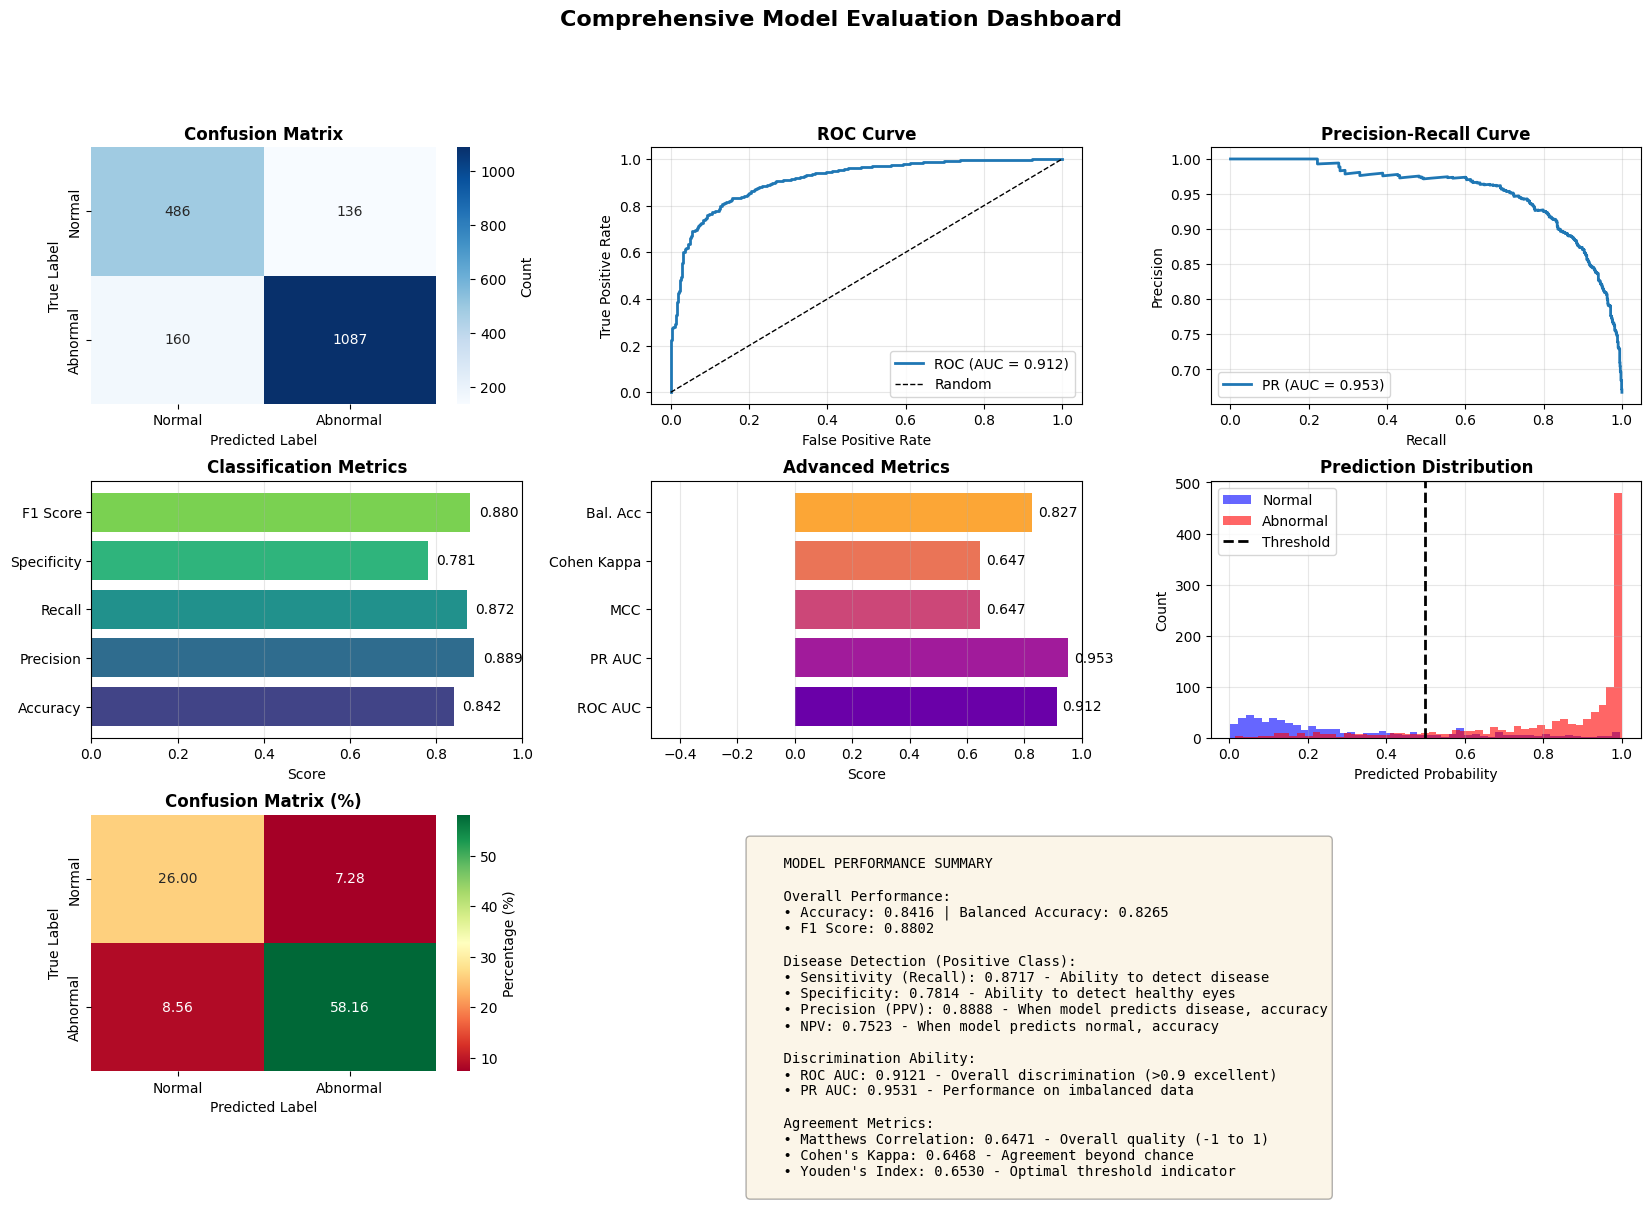

In [19]:
# Create evaluator
evaluator = ModelEvaluator(model, device, class_names=['Normal', 'Abnormal'])

# Evaluate on validation set
print("Evaluating on Validation Set...")
val_metrics = evaluator.evaluate(val_loader, threshold=0.5)

# Print metrics
evaluator.print_metrics(val_metrics)

# Visualize
plot_comprehensive_analysis(val_metrics, save_path='validation_evaluation.png')

## 6.4 Evaluate on Test Set (Final Performance)

Evaluating on Test Set...


Evaluating: 100%|██████████| 117/117 [00:05<00:00, 21.19it/s]



COMPREHENSIVE MODEL EVALUATION METRICS

--- Confusion Matrix Components ---
True Positives (TP):    1106
True Negatives (TN):     467
False Positives (FP):    154
False Negatives (FN):    142

--- Classification Metrics ---
Accuracy:              0.8416
Balanced Accuracy:     0.8191
Precision (PPV):       0.8778
Recall (Sensitivity):  0.8862
Specificity:           0.7520
NPV:                   0.7668
F1 Score:              0.8820

--- Advanced Metrics ---
ROC AUC:               0.9077
PR AUC:                0.9524
Matthews Corr Coef:    0.6414
Cohen's Kappa:         0.6413
Youden's Index:        0.6382


Plot saved to: test_evaluation.png


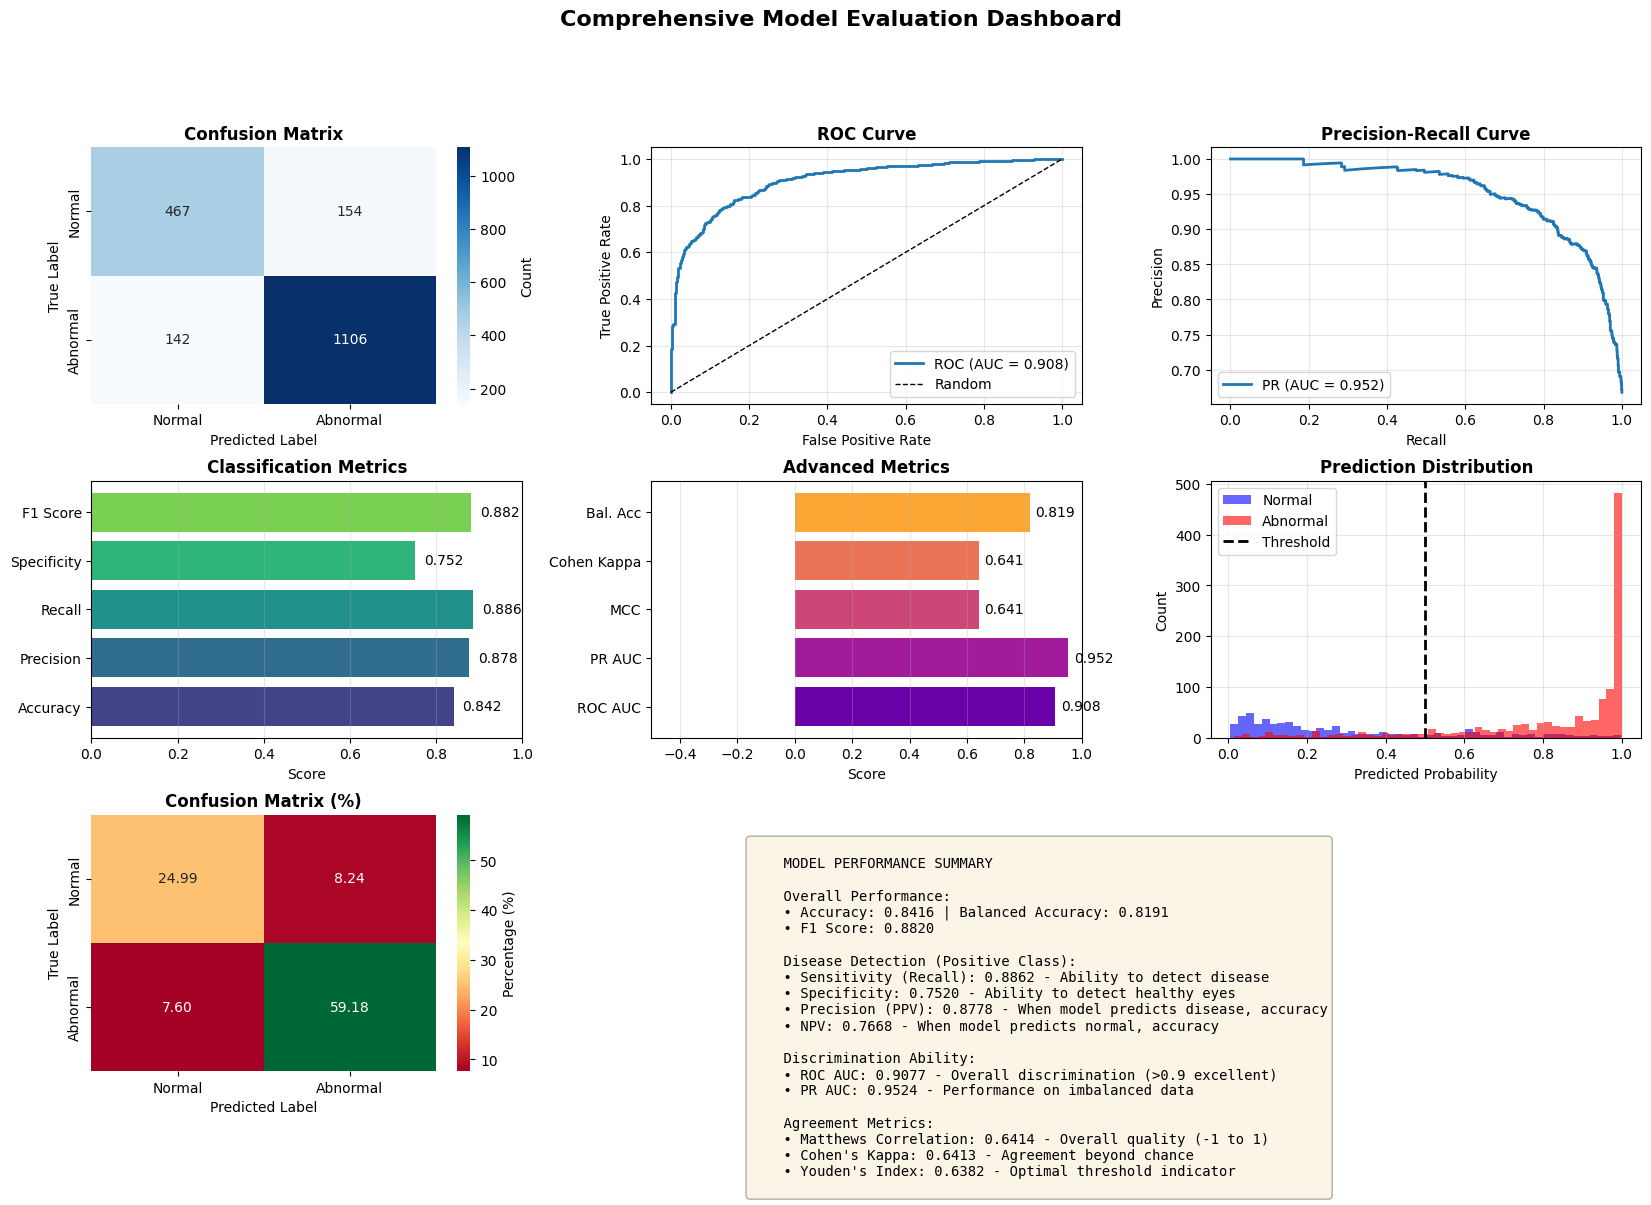

In [20]:
# Evaluate on test set
print("Evaluating on Test Set...")
test_metrics = evaluator.evaluate(test_loader, threshold=0.5)

# Print metrics
evaluator.print_metrics(test_metrics)

# Visualize
plot_comprehensive_analysis(test_metrics, save_path='test_evaluation.png')

## 6.5 Find Optimal Classification Threshold

Finding optimal threshold: 100%|██████████| 117/117 [00:05<00:00, 22.14it/s]


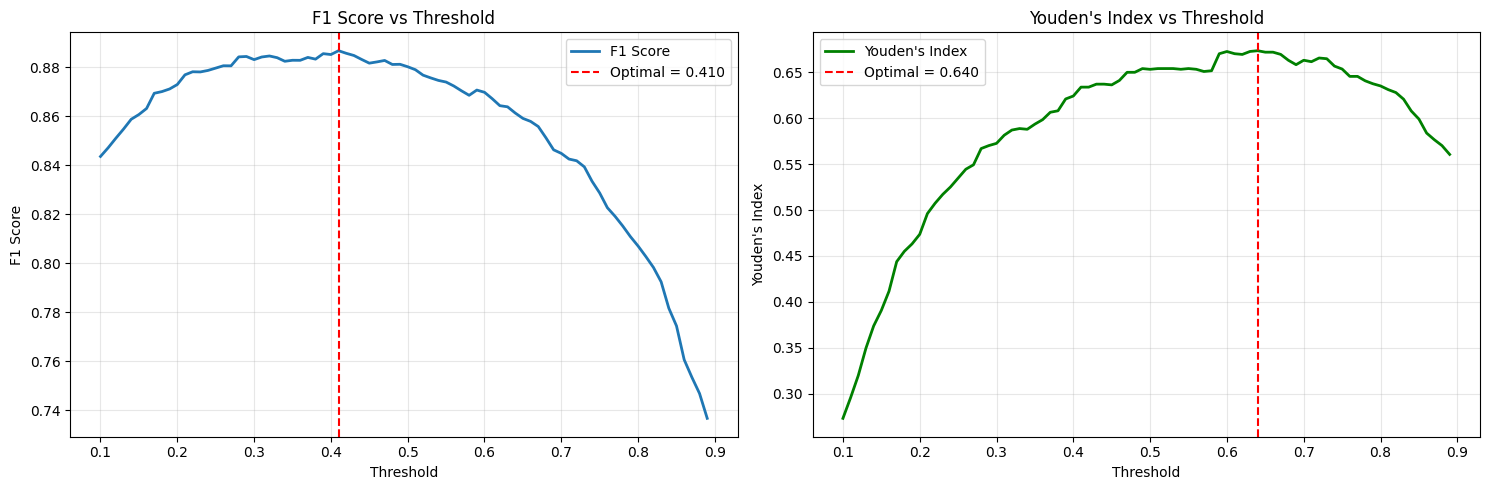


Optimal threshold (f1): 0.410
Best f1 score: 0.8867


Finding optimal threshold: 100%|██████████| 117/117 [00:05<00:00, 21.71it/s]


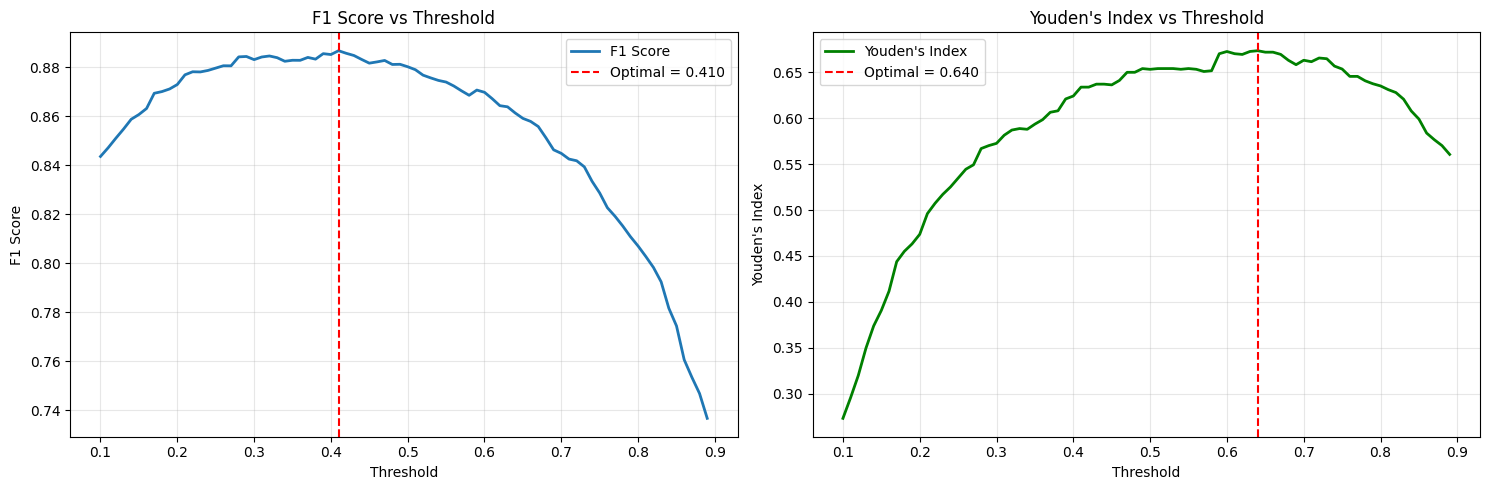


Optimal threshold (youden): 0.640
Best youden score: 0.6733


In [21]:
def find_optimal_threshold(model, dataloader, device, metric='f1'):
    """Find optimal classification threshold"""
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc="Finding optimal threshold"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            all_probs.append(outputs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    y_true = all_labels[:, 1]
    y_prob = all_probs[:, 1]

    thresholds = np.arange(0.1, 0.9, 0.01)
    best_score = 0
    best_threshold = 0.5

    f1_scores = []
    youden_scores = []

    for thresh in thresholds:
        y_pred = (y_prob > thresh).astype(int)

        # F1 Score
        f1 = f1_score(y_true, y_pred)
        f1_scores.append(f1)

        # Youden's Index
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        youden = sensitivity + specificity - 1
        youden_scores.append(youden)

        if metric == 'f1' and f1 > best_score:
            best_score = f1
            best_threshold = thresh
        elif metric == 'youden' and youden > best_score:
            best_score = youden
            best_threshold = thresh

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(thresholds, f1_scores, linewidth=2, label='F1 Score')
    axes[0].axvline(best_threshold if metric == 'f1' else thresholds[np.argmax(f1_scores)],
                   color='r', linestyle='--', label=f'Optimal = {thresholds[np.argmax(f1_scores)]:.3f}')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('F1 Score')
    axes[0].set_title('F1 Score vs Threshold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(thresholds, youden_scores, linewidth=2, label="Youden's Index", color='green')
    axes[1].axvline(best_threshold if metric == 'youden' else thresholds[np.argmax(youden_scores)],
                   color='r', linestyle='--', label=f'Optimal = {thresholds[np.argmax(youden_scores)]:.3f}')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel("Youden's Index")
    axes[1].set_title("Youden's Index vs Threshold")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nOptimal threshold ({metric}): {best_threshold:.3f}")
    print(f"Best {metric} score: {best_score:.4f}")

    return best_threshold, best_score

# Find optimal threshold on validation set
optimal_thresh_f1, _ = find_optimal_threshold(model, val_loader, device, metric='f1')
optimal_thresh_youden, _ = find_optimal_threshold(model, val_loader, device, metric='youden')

## 6.6 Re-evaluate with Optimal Threshold


Re-evaluating with optimal threshold: 0.410


Evaluating: 100%|██████████| 117/117 [00:05<00:00, 21.87it/s]



COMPREHENSIVE MODEL EVALUATION METRICS

--- Confusion Matrix Components ---
True Positives (TP):    1137
True Negatives (TN):     440
False Positives (FP):    181
False Negatives (FN):    111

--- Classification Metrics ---
Accuracy:              0.8438
Balanced Accuracy:     0.8098
Precision (PPV):       0.8627
Recall (Sensitivity):  0.9111
Specificity:           0.7085
NPV:                   0.7985
F1 Score:              0.8862

--- Advanced Metrics ---
ROC AUC:               0.9077
PR AUC:                0.9524
Matthews Corr Coef:    0.6401
Cohen's Kappa:         0.6376
Youden's Index:        0.6196


Plot saved to: test_evaluation_optimal_threshold.png


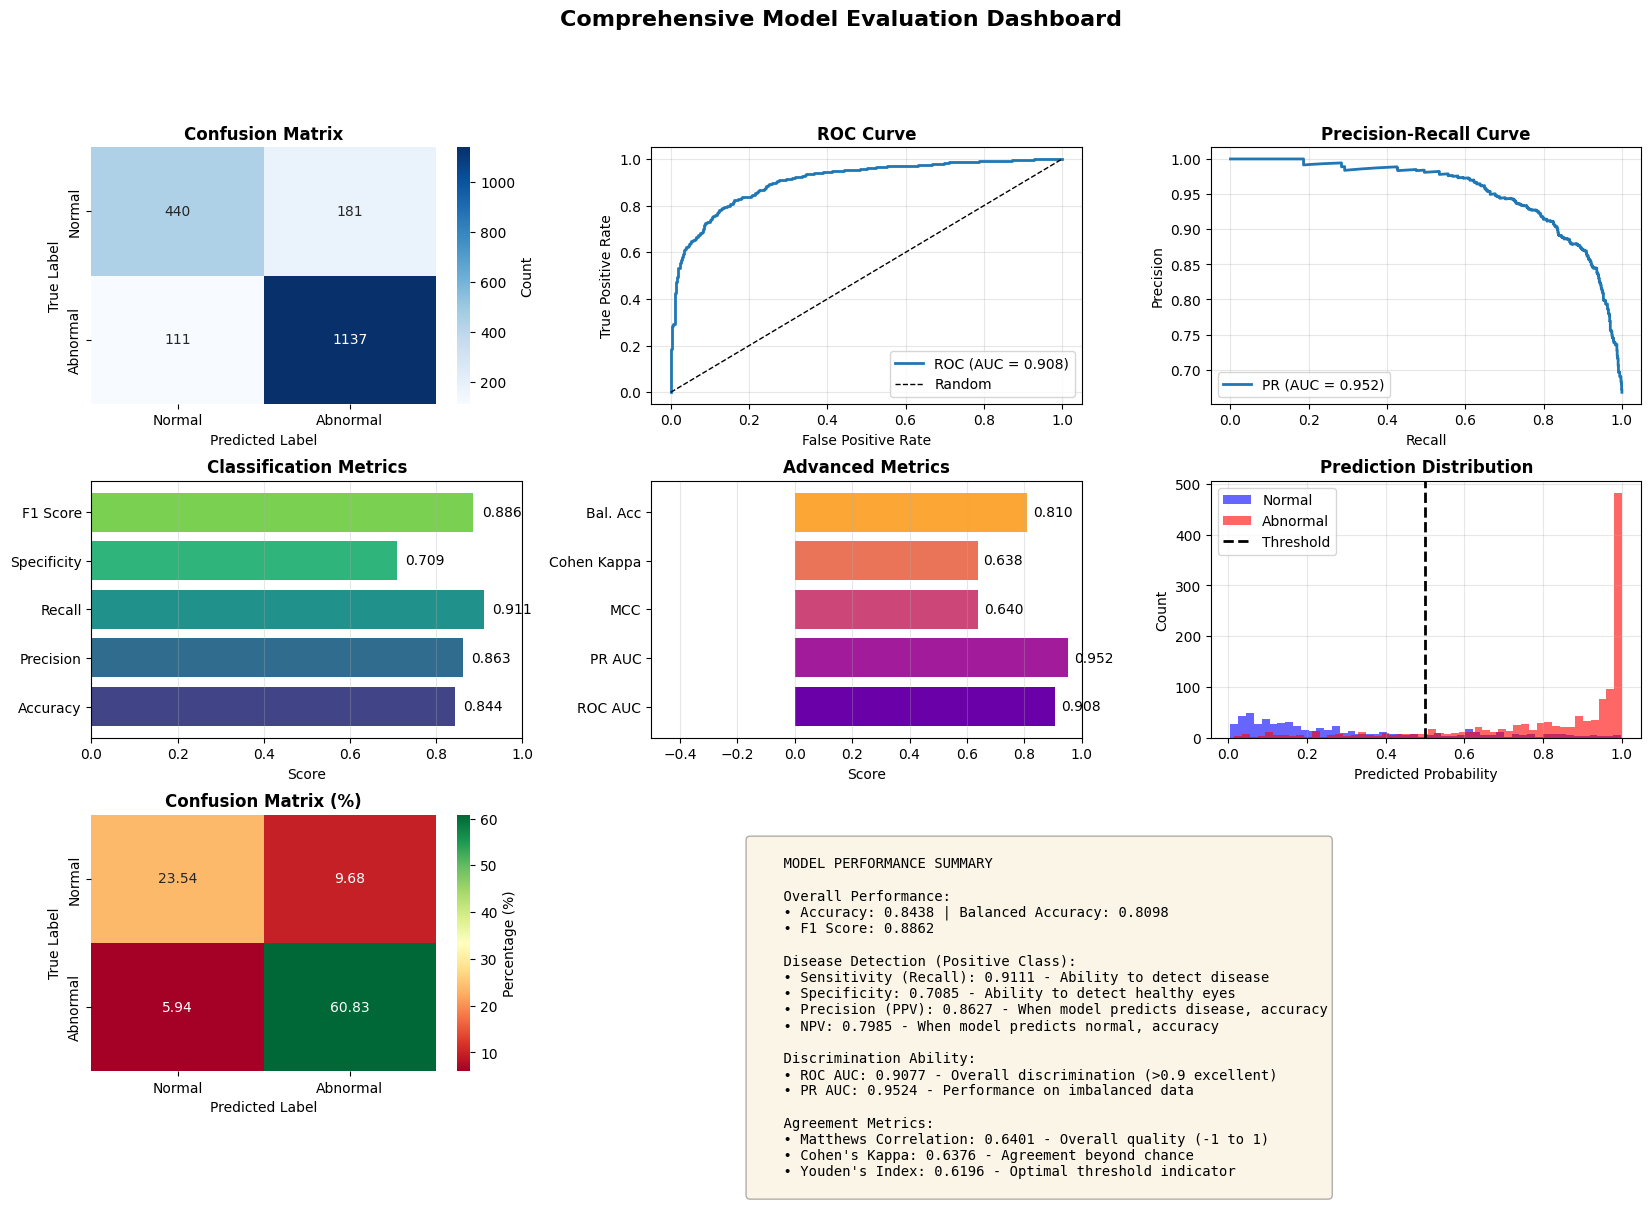

In [22]:
# Re-evaluate with optimal threshold
print(f"\nRe-evaluating with optimal threshold: {optimal_thresh_f1:.3f}")
test_metrics_optimal = evaluator.evaluate(test_loader, threshold=optimal_thresh_f1)

# Print and visualize
evaluator.print_metrics(test_metrics_optimal)
plot_comprehensive_analysis(test_metrics_optimal, save_path='test_evaluation_optimal_threshold.png')

# 7. Error Analysis

## 7.1 Visualize Misclassified Examples

Finding misclassifications: 100%|██████████| 1869/1869 [00:20<00:00, 91.65it/s]


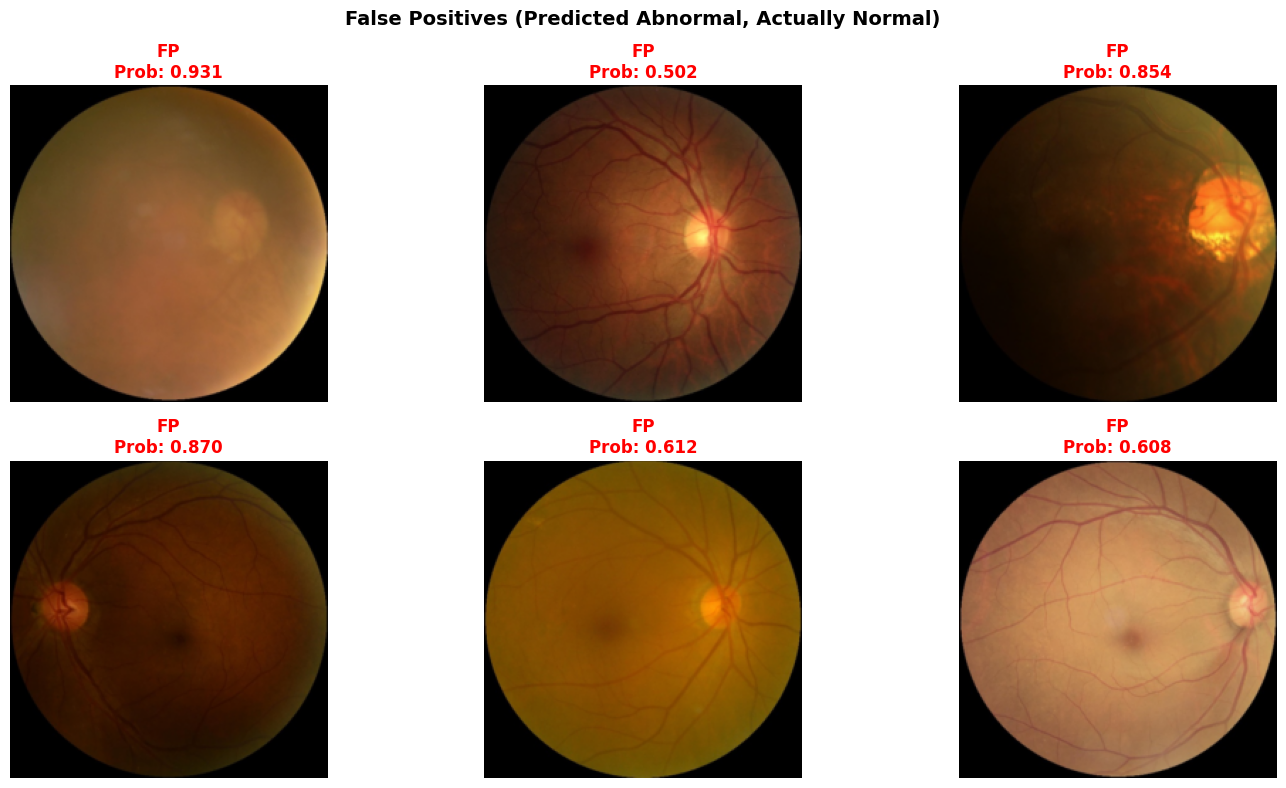

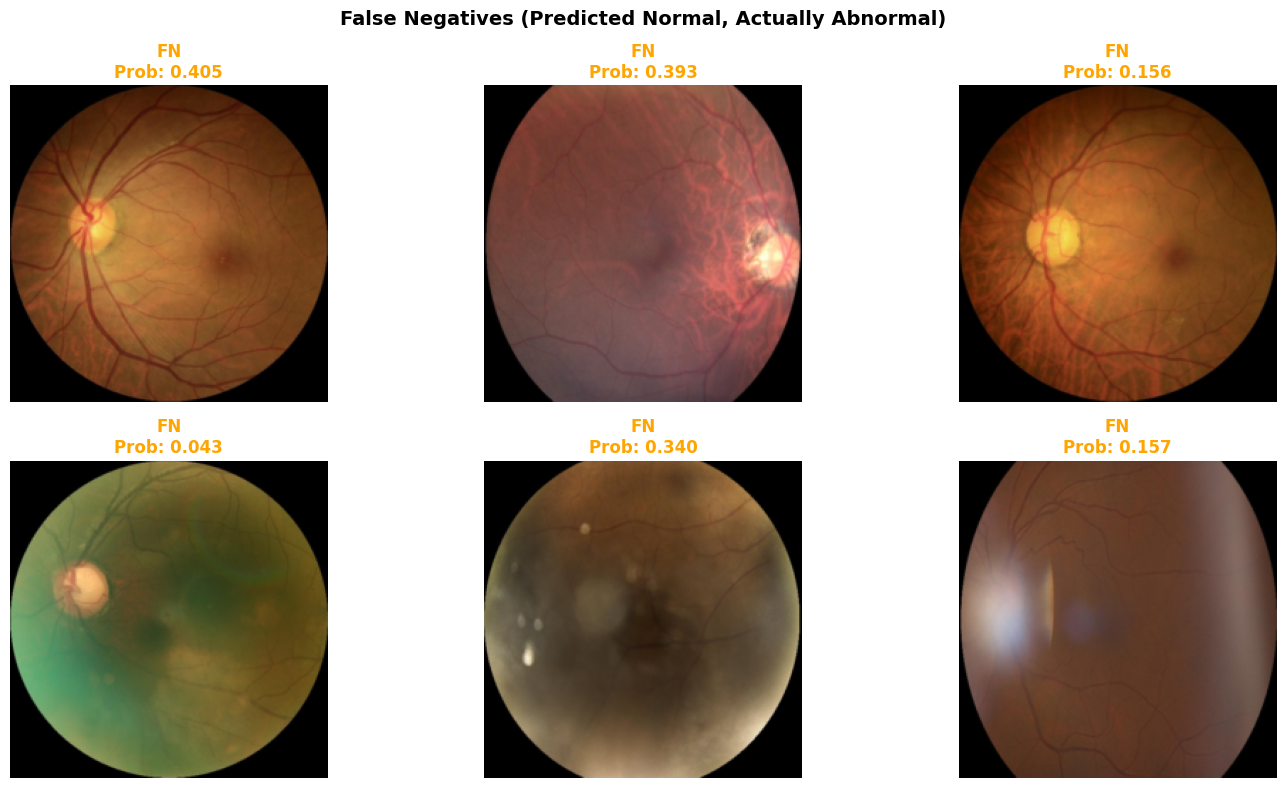


Found 154 false positives and 142 false negatives


In [23]:
def visualize_misclassifications(model, dataset, device, num_examples=12):
    """Visualize misclassified examples"""
    model.eval()

    false_positives = []
    false_negatives = []

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="Finding misclassifications"):
            img, label = dataset[idx]
            img_tensor = img.unsqueeze(0).to(device)
            output = model(img_tensor)
            pred = (output > 0.5).cpu().numpy()[0]

            true_label = label[1].item()  # Abnormal class
            pred_label = pred[1]

            if true_label == 0 and pred_label == 1:
                false_positives.append((idx, img, output[0, 1].item()))
            elif true_label == 1 and pred_label == 0:
                false_negatives.append((idx, img, output[0, 1].item()))

    # Plot false positives
    if false_positives:
        plt.figure(figsize=(15, 8))
        for i, (idx, img, prob) in enumerate(false_positives[:num_examples//2]):
            img_display = img.permute(1, 2, 0).numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)

            plt.subplot(2, num_examples//4, i+1)
            plt.imshow(img_display)
            plt.title(f"FP\nProb: {prob:.3f}", color='red', fontweight='bold')
            plt.axis('off')
        plt.suptitle("False Positives (Predicted Abnormal, Actually Normal)", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # Plot false negatives
    if false_negatives:
        plt.figure(figsize=(15, 8))
        for i, (idx, img, prob) in enumerate(false_negatives[:num_examples//2]):
            img_display = img.permute(1, 2, 0).numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)

            plt.subplot(2, num_examples//4, i+1)
            plt.imshow(img_display)
            plt.title(f"FN\nProb: {prob:.3f}", color='orange', fontweight='bold')
            plt.axis('off')
        plt.suptitle("False Negatives (Predicted Normal, Actually Abnormal)", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    print(f"\nFound {len(false_positives)} false positives and {len(false_negatives)} false negatives")

# Visualize misclassifications
visualize_misclassifications(model, test_ds, device, num_examples=12)

# 8. Model Comparison Summary

## 8.1 Compare Original vs Improved Model

In [ ]:
print("="*70)
print("KEY IMPROVEMENTS IMPLEMENTED")
print("="*70)
print("""
1. ✓ Separate transforms for training and validation
   - Training: WITH augmentation
   - Validation/Test: WITHOUT augmentation

2. ✓ Better model architecture
   - ResNet34 instead of ResNet18
   - Improved classifier head with BatchNorm
   - Better dropout regularization

3. ✓ Learning rate scheduling
   - CosineAnnealingWarmRestarts
   - Prevents learning plateaus

4. ✓ Three-way data split
   - Train: 70%, Val: 15%, Test: 15%
   - Proper evaluation on unseen data

5. ✓ Comprehensive evaluation metrics
   - 15+ metrics including ROC AUC, PR AUC, MCC, Cohen's Kappa
   - Advanced visualizations
   - Threshold optimization

6. ✓ Better training monitoring
   - Real-time visualization
   - Early stopping with patience
   - Learning rate tracking

7. ✓ Error analysis
   - Misclassification visualization
   - Prediction probability distributions
""")
print("="*70)

# 9. Save and Export

## 9.1 Save Final Model and Results

In [24]:
# Save complete model checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'test_metrics': test_metrics_optimal,
    'optimal_threshold': optimal_thresh_f1,
    'history': history,
    'class_names': ['Normal', 'Abnormal']
}, 'final_model_complete.pth')

print("✓ Final model saved to: final_model_complete.pth")

# Save metrics to CSV
metrics_df = pd.DataFrame([
    {
        'Metric': 'Accuracy',
        'Value': test_metrics_optimal['accuracy']
    },
    {
        'Metric': 'Precision',
        'Value': test_metrics_optimal['precision']
    },
    {
        'Metric': 'Recall',
        'Value': test_metrics_optimal['recall']
    },
    {
        'Metric': 'F1 Score',
        'Value': test_metrics_optimal['f1_score']
    },
    {
        'Metric': 'ROC AUC',
        'Value': test_metrics_optimal['roc_auc']
    },
    {
        'Metric': 'PR AUC',
        'Value': test_metrics_optimal['pr_auc']
    }
])

metrics_df.to_csv('model_metrics.csv', index=False)
print("✓ Metrics saved to: model_metrics.csv")

print("\n" + "="*70)
print("NOTEBOOK EXECUTION COMPLETE")
print("="*70)

✓ Final model saved to: final_model_complete.pth
✓ Metrics saved to: model_metrics.csv

NOTEBOOK EXECUTION COMPLETE
